In [40]:
import numpy as np
from scipy import stats as stats
import matplotlib.pyplot as plt
def generate_data(n,p):
    epsilon = 0.01
    size = (n,p)
    y_size = (n,1)
    x = np.random.normal(size=size)
    y = np.random.randint(0,2,size=y_size)
    return x,y

X, y = generate_data(50,2)

def sigmoid(x):
    return 1 / (1 +np.exp(-x))

def grad_sigmoid(x):
    return sigmoid(x)*(1-sigmoid(x))

def y_hat(X,w):
    return sigmoid(X@w)
def grad_y_hat(X,w):
    z = X@w
    return X.T


def BCE(y,y_hat):
    return np.mean(-y*np.log(y_hat)-(1-y)*np.log(1-y_hat))

def grad_BCE(y,X,w):
    prediction = y_hat(X,w)
    return -X.T@(y - prediction)

num_epochs=1000
def training(X,y,num_epochs=100,eta=0.01):
    size=X.shape[1]
    weights = np.random.normal(size=(size,1))
    weights_storage = []
    loss_storage = []
    for epoch in range(num_epochs):
        prediction = y_hat(X,weights)
        weights_storage.append(weights)
        loss = BCE(y,prediction)
        loss_storage.append(loss)
        weights = weights - eta*grad_BCE(y,X,weights)
        if epoch % 100 == 0:
            print(f"Epoch number {epoch}, weights {weights}")
    return weights_storage, loss_storage
    
storage, loss_storage = training(X,y,num_epochs=num_epochs)

Epoch number 0, weights [[ 0.77647318]
 [-0.55248877]]
Epoch number 100, weights [[-0.31537881]
 [-0.0517431 ]]
Epoch number 200, weights [[-0.31538343]
 [-0.05173444]]
Epoch number 300, weights [[-0.31538343]
 [-0.05173444]]
Epoch number 400, weights [[-0.31538343]
 [-0.05173444]]
Epoch number 500, weights [[-0.31538343]
 [-0.05173444]]
Epoch number 600, weights [[-0.31538343]
 [-0.05173444]]
Epoch number 700, weights [[-0.31538343]
 [-0.05173444]]
Epoch number 800, weights [[-0.31538343]
 [-0.05173444]]
Epoch number 900, weights [[-0.31538343]
 [-0.05173444]]


Text(0.5, 1.0, 'Loss function of 1000 iteration')

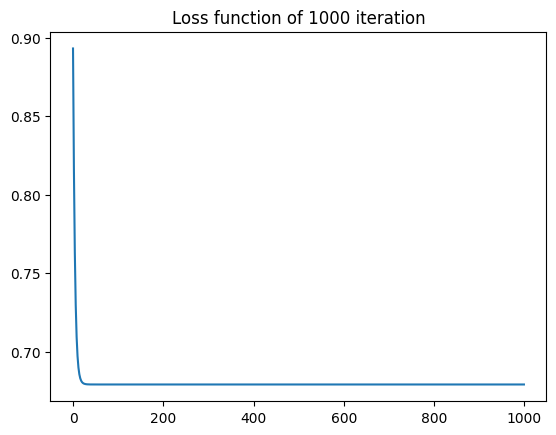

In [41]:
plt.plot(loss_storage)
plt.title(f"Loss function of {num_epochs} iteration")

In [42]:
storage = np.array(storage)

In [43]:
storage = storage[:,:,-1]
storage.shape

(1000, 2)

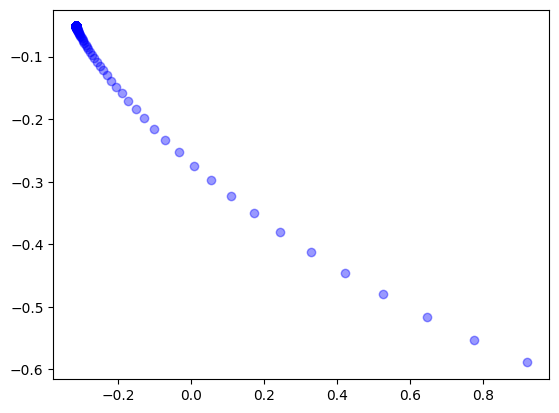

In [44]:
for x,y in storage:
    plt.scatter(x,y,color='blue',alpha=0.4)

# Standard Linear Regression

In [45]:
def generate_data(n,p):
    epsilon = 0.01
    size = (n,p)
    y_size = (n,1)
    x = np.random.normal(loc=1,scale=1,size=size)
    y = np.random.normal(0,2,size=y_size)
    return x,y

n = 50
p = 2
X_, y = generate_data(n,p)


def prediction(X,w,b):
    return X@w+b
def MSE(y,y_hat):
    return np.mean((y-y_hat)**2) / 2
def grad_MSE_b(y,X,w,b):
    return np.sum(X@w + b - y)
def grad_MSE_w(y,X,w,b):
    y_hat = prediction(X,w,b)
    return X.T@(y_hat-y)

def training_L(X,y,num_epochs=100,eta=0.01):
    size=X.shape[1]
    weights = np.random.normal(size=(size,1))
    bias = np.random.normal(1)*np.ones_like(y)
    storage = []
    loss_storage = []
    for epoch in range(num_epochs):
        storage.append(weights)
        loss = MSE(y,prediction(X_,weights,bias))
        loss_storage.append(loss)
        if epoch % 100 == 0 :
            print(f"Epoch number {epoch}, weights {weights}, bias {bias[0]}")
        weights = weights - eta*grad_MSE_w(y,X_,weights,bias)
        bias = bias - eta*grad_MSE_b(y,X_,weights,bias)
    return storage, weights, bias
    
storage, weights, bias = training_L(X_,y,num_epochs=num_epochs)
storage=np.array(storage)
storage = storage[:,:,-1]

Epoch number 0, weights [[ 0.49404835]
 [-0.93361988]], bias [0.65154165]
Epoch number 100, weights [[ 0.0879669 ]
 [-0.16505572]], bias [-0.20104856]
Epoch number 200, weights [[ 0.0879669 ]
 [-0.16505572]], bias [-0.20104856]
Epoch number 300, weights [[ 0.0879669 ]
 [-0.16505572]], bias [-0.20104856]
Epoch number 400, weights [[ 0.0879669 ]
 [-0.16505572]], bias [-0.20104856]
Epoch number 500, weights [[ 0.0879669 ]
 [-0.16505572]], bias [-0.20104856]
Epoch number 600, weights [[ 0.0879669 ]
 [-0.16505572]], bias [-0.20104856]
Epoch number 700, weights [[ 0.0879669 ]
 [-0.16505572]], bias [-0.20104856]
Epoch number 800, weights [[ 0.0879669 ]
 [-0.16505572]], bias [-0.20104856]
Epoch number 900, weights [[ 0.0879669 ]
 [-0.16505572]], bias [-0.20104856]


Text(0.5, 1.0, 'Loss function of 1000 iteration')

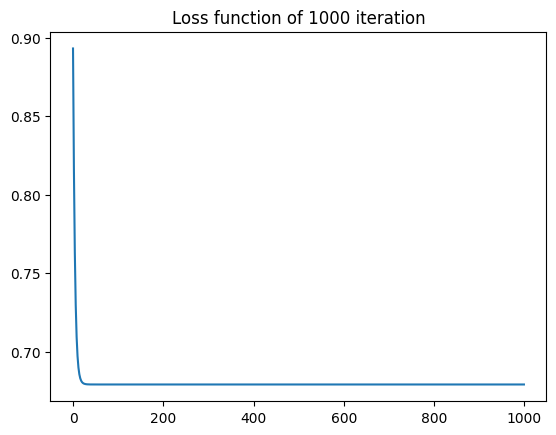

In [46]:
plt.plot(loss_storage)
plt.title(f"Loss function of {num_epochs} iteration")

Text(0.5, 0.5, 'Y Label')

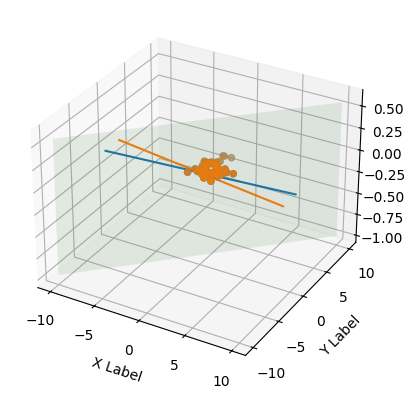

In [47]:
u = np.linspace(-10,10,50)
v = np.linspace(-10,10,50)
grid = np.meshgrid(u,v)
w = weights
b = bias
ax = plt.figure().add_subplot(projection='3d')
for i,vec in enumerate([u,v]):
    ax.plot(vec,w[i]*vec+b)

for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
    xs = X_[:,0]
    ys = X_[:,1]
    zs = y
    ax.scatter(xs, ys)
ax.plot_surface(u,v,prediction(np.column_stack([u,v]),weights,b),alpha=0.1)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')


In [48]:
weights.mean(),bias[0]

(np.float64(-0.038544411288502514), array([-0.20104856]))

# Hyperbolic Tanget

\begin{align*}\tanh(x) &= \frac{e^{x}+e^{-x}}{e^x-e^{-x}}\\
&= \frac{e^x}{e^x-e^{-x}}+\frac{e^{-x}}{e^x-e^{-x}} \\
&= \frac{1}{1-e^{-2x}}+\frac{e^x-e^{-x}+e^{-x}}{e^x-e^{-x}}\\
&= \frac{2}{1-e^{-2x}}-1\\
&= \sigma(2x)-1
\end{align*}
where $\sigma(u)$ is the sigmoid function.

In [49]:
### hyperbolic tangent activation

def tanh_(x):
    return 2*sigmoid(2*x)-1

def grad_tanh(x):
    return 4*grad_sigmoid(2*x)

def change_target(y):
    return (1 + y) / 2

def grad_MSE_uw(y,X,w,b):
    y_hat = prediction(X,w,b)
    u = 2*y_hat
    return 2*X.T@grad_sigmoid(u)

def grad_MSE_ub(y,X,w,b):
    y_hat = prediction(X,w,b)
    u = 2*y_hat
    return 2*np.sum(grad_sigmoid(u))



def training_Lbt(X,y,num_epochs=100,eta=0.01):
    size=X.shape[1]
    weights = np.random.normal(size=(size,1))
    bias = np.random.normal(1)*np.ones_like(y)
    storage = []
    loss_storage = []
    y = change_target(y)
    for epoch in range(num_epochs):
        storage.append(weights)
        loss = MSE(change_target(y),tanh_(prediction(X,weights,bias)))
        loss_storage.append(loss)
        if epoch % 100 ==0:
            print(f"Epoch number {epoch},\n weights \n {weights}, \n bias {bias[0]}")
        weights = weights - eta*grad_MSE_uw(y,X,weights,bias)
        bias = bias - eta*grad_MSE_ub(y,X,weights,bias)
    return storage, weights, bias

storage,weights,bias = training_Lbt(X,y,num_epochs=num_epochs)

Epoch number 0,
 weights 
 [[1.39039429]
 [0.47202119]], 
 bias [1.12271926]
Epoch number 100,
 weights 
 [[ 0.0901718 ]
 [-0.02456498]], 
 bias [-2.66394296]
Epoch number 200,
 weights 
 [[ 0.00479802]
 [-0.04429563]], 
 bias [-3.00466361]
Epoch number 300,
 weights 
 [[-0.0218207 ]
 [-0.05030981]], 
 bias [-3.20245939]
Epoch number 400,
 weights 
 [[-0.03473464]
 [-0.05317117]], 
 bias [-3.34334089]
Epoch number 500,
 weights 
 [[-0.04231417]
 [-0.05482283]], 
 bias [-3.45299547]
Epoch number 600,
 weights 
 [[-0.04727703]
 [-0.05588861]], 
 bias [-3.54282516]
Epoch number 700,
 weights 
 [[-0.05076776]
 [-0.05662848]], 
 bias [-3.61892653]
Epoch number 800,
 weights 
 [[-0.05335069]
 [-0.05716946]], 
 bias [-3.68495053]
Epoch number 900,
 weights 
 [[-0.05533557]
 [-0.05758063]], 
 bias [-3.74325933]


Text(0.5, 1.0, 'Loss function of 1000 iteration')

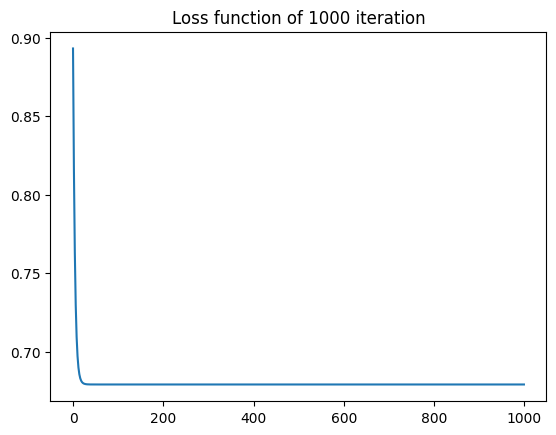

In [50]:
plt.plot(loss_storage)
plt.title(f"Loss function of {num_epochs} iteration")

Text(0.5, 0.5, 'Y Label')

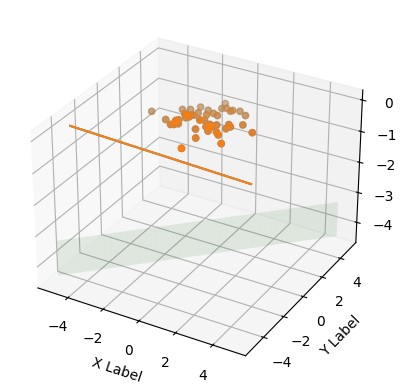

In [52]:
u = np.linspace(-5,5,50)
v = np.linspace(-5,5,50)
grid = np.meshgrid(u,v)
w = weights
b = bias
ax = plt.figure().add_subplot(projection='3d')
for i,vec in enumerate([u,v]):
    ax.plot(vec,w[i]*vec+b)

for m, zlow, zhigh in [('o', -50, -25), ('^', -30, -5)]:
    xs = X[:,0]
    ys = X[:,1]
    zs = change_target(y)
    ax.scatter(xs, ys)
ax.plot_surface(u,v,prediction(np.column_stack([u,v]),weights,b),alpha=0.1)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')